# Explore here

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
df = pd.read_csv(
    "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:

X = df.drop("Outcome", axis=1)
y = df["Outcome"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = GradientBoostingClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

Accuracy: 0.7467532467532467

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



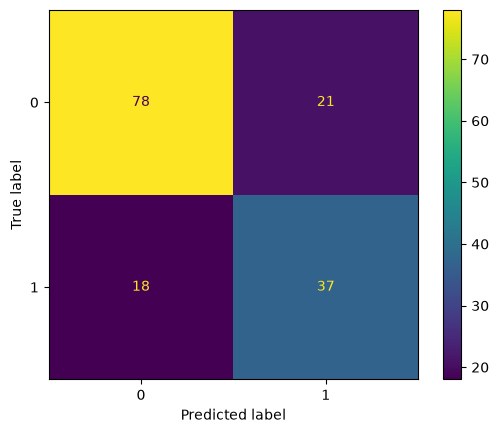

In [8]:
y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### Análisis del modelo de Gradient Boosting

El modelo de **Gradient Boosting** obtuvo una precisión (**accuracy**) de **74.68%** sobre el conjunto de prueba. De acuerdo con el reporte de clasificación, el modelo presenta un mejor desempeño en la predicción de la clase **0** (pacientes sin diabetes) que de la clase **1** (pacientes con diabetes). La matriz de confusión permite observar la distribución de aciertos y errores del modelo, proporcionando una referencia inicial antes de realizar ajustes en sus hiperparámetros para evaluar posibles mejoras en el rendimiento.

## Paso 2: Construcción del modelo de Boosting

In [9]:
learning_rates = [0.01, 0.1, 0.2]
n_estimators = [50, 100, 200]

results = []

for lr in learning_rates:
    for n in n_estimators:

        model = GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=n,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        results.append({
            "Learning Rate": lr,
            "Estimators": n,
            "Accuracy": accuracy
        })

results = pd.DataFrame(results)

results

,Learning Rate,Estimators,Accuracy
0,0.01,50,0.727273
1,0.01,100,0.785714
2,0.01,200,0.772727
3,0.10,50,0.766234
4,0.10,100,0.746753
5,0.10,200,0.733766
6,0.20,50,0.740260
7,0.20,100,0.688312
8,0.20,200,0.720779


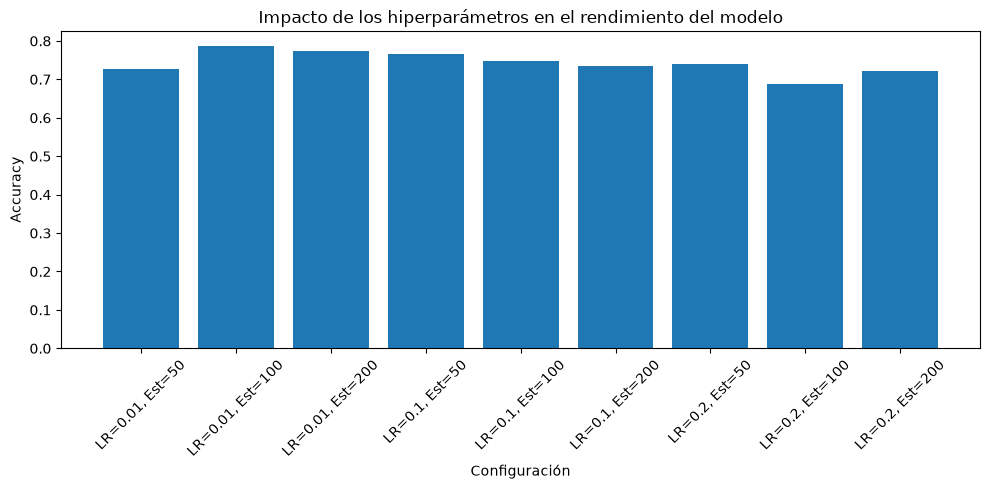

In [10]:
results["Configuración"] = (
    "LR=" + results["Learning Rate"].astype(str) +
    ", Est=" + results["Estimators"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.bar(results["Configuración"], results["Accuracy"])

plt.xticks(rotation=45)
plt.xlabel("Configuración")
plt.ylabel("Accuracy")
plt.title("Impacto de los hiperparámetros en el rendimiento del modelo")

plt.tight_layout()
plt.show()

### Conclusiones del ajuste de hiperparámetros

Se evaluaron distintas combinaciones de los hiperparámetros **learning_rate** y **n_estimators** para analizar su impacto en el rendimiento del modelo. Los resultados muestran que la combinación **learning_rate = 0.01** y **n_estimators = 100** obtuvo el mejor desempeño, alcanzando un **accuracy de 78.57%**. En general, se observa que pequeños cambios en los hiperparámetros influyen directamente en la precisión del modelo, por lo que su ajuste resulta fundamental para obtener un mejor rendimiento.

## Paso 3: Guardado del modelo

In [11]:
best_model = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=100,
    random_state=42
)

best_model.fit(X_train, y_train)

joblib.dump(best_model, "../models/gradient_boosting_classifier.pkl")

['../models/gradient_boosting_classifier.pkl']

## Paso 4: Comparación de modelos

### Comparación de modelos

| Modelo | Accuracy |
|---------|---------:|
| Árbol de Decisión | **69.48%** |
| Random Forest | **76.00%** |
| Gradient Boosting | **78.57%** |

### Conclusión

Al comparar los tres modelos, se observa una mejora progresiva en el rendimiento. El Árbol de Decisión obtuvo la menor precisión (69.48%), mientras que Random Forest mejoró el desempeño al combinar múltiples árboles de decisión, alcanzando aproximadamente un 76% de accuracy. Finalmente, Gradient Boosting obtuvo el mejor resultado con una precisión de **78.57%**, por lo que se selecciona como el modelo más adecuado para este conjunto de datos.

En los tres modelos, la **clase 0 (pacientes sin diabetes)** obtuvo mejores métricas de precisión y recall que la **clase 1 (pacientes con diabetes)**, por lo que la predicción de la clase 1 continúa siendo el mayor desafío del problema.